# Лабораторная работа 3. Нейронные сети в NLP.

Результатом лабораторной работы является отчет. Мы предпочитаем принимать отчеты в формате ноутбуков IPython (ipynb-файл). Постарайтесь сделать ваш отчет интересным рассказом, последовательно отвечающим на вопросы из заданий. Помимо ответов на вопросы, в отчете также должен быть код, однако чем меньше кода, тем лучше всем: нам — меньше проверять, вам — проще найти ошибку или дополнить эксперимент. При проверке оценивается четкость ответов на вопросы, аккуратность отчета и кода.

Мы уверены, что выполнение лабораторных работ занимает значительное время, поэтому не рекомендуем оставлять их на последний вечер перед сдачей.

## Рекуррентные языковые модели и трансформеры (16 баллов + бонусные 0-11 баллов)

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSj85jp-W-V-Bz8ZBjFJYIkV1TTxQxTMh4iqls_rRt8O-sraL08PA)

В этой части домашней работы мы создадим языковую модель на рекуррентных нейросетях (RNN) и заставим её придумывать имена.

__Языковая модель__, если вкратце, — это модель, которая умеет предсказывать вероятность некоторого текста. Ее можно использовать также для генерирации нового текста в соответствии с обученными вероятностями. Задание будет заключаться в том, чтобы научить модель генерировать новые имена, скормив ей для этого 8к существующих.

В данном случае в качестве входных данных мы будет работать со строками, которые можно рассматривать как последовательности _символов_: $\{x_0, x_1, x_2, ..., x_n\}$.

Наша основная задача — научиться предсказывать вероятность следующего символа:
$$ p(x_0, x_1, x_2, ..., x_n) = \prod_t p(x_t | x_0, ... x_{t - 1}) $$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Данные

Мы будем строить языковую модель по ~8k человеческих имён на латинице. Если когда-нибудь вам нужно будет дать имя своему ребёнку, у вас будет для этого генеративная нейросетевая модель.

Давайте их прочитаем:
* Считайте все строки из файла `names` в список
* В начало каждой строки допишите __пробел__
* В конце сроки не должно быть переноса (`\n`)

In [ ]:
import os
start_token = " "

# YOUR CODE

In [ ]:
assert all(line[0] == start_token for line in lines)
assert all(line[-1] != '\n' for line in lines)

In [ ]:
print ('n samples = ',len(lines))
for x in lines[::1000]:
    print (x)

Проверьте, что все корректно:

In [ ]:
MAX_LENGTH = max(map(len, lines))
print("max length =", MAX_LENGTH)
assert MAX_LENGTH == 16 , "max length (for names) should be 16. remove assert if you work on different dataset"

## Словари

В начале нам будет необходимо построить "словарь" — упорядоченное множество уникальных символов, которые сеть может породить. Это нужно, чтобы уметь сопоставить каждому символу свой номер. Перед отправкой в сеть все символы будут кодироваться их номерами в словаре.

Также необходимо добавить в словарь пробельный символ, который будет использоваться в качестве специального токена.

In [ ]:
tokens = #YOUR CODE

tokens = sorted(list(tokens))

n_tokens = len(tokens)
print ('n_tokens = ',n_tokens)

assert 50 < n_tokens < 60

А теперь построим обратный словарь: для каждой буквы посчитаем её номер в списке токенов.

In [ ]:
token_to_id = # YOUR CODE

И проверим, все ли корректно:

In [ ]:
assert len(tokens) == len(token_to_id), "число токенов должно совпадать"

for i in range(n_tokens):
    assert token_to_id[tokens[i]] == i, "словарь должен указывать на индекс буквы в tokens"

print("Кажется заработало...")

Имея построенное соответствие, можно преобразовать батч входных данных в матрицу int32 номеров токенов. Так как в батче все строки должны быть одной длины, слишком короткие строки в батче нужно будет дополнить пробелами (паддинг).

In [ ]:
def to_matrix(lines, max_len=None, pad=token_to_id[' '], dtype='int32'):
    """Casts a list of names into rnn-digestable matrix"""
    max_len = max_len or max(map(len, lines))
    lines_ix = np.zeros([len(lines), max_len], dtype) + pad

    for i in range(len(lines)):
        line_ix = list(map(token_to_id.get, lines[i]))
        lines_ix[i, :len(line_ix)] = line_ix

    return lines_ix

In [ ]:
print('\n'.join(lines[::2000]))
print(to_matrix(lines[::2000]))

## Один шаг RNN

Рекуррентная нейронная сеть (RNN) — это такая сеть с <s>блокнотом</s> состоянием $h$, в который она умеет писать то, что видела.

Сеть начинает с пустого $h_0 = \vec 0$, после чего текст обрабатывается по одному символу:
* $x_t$ — очередной символ, $h_t$ — предыдущее состояние
* $h_{t+1} = \text{get\_h\_next}(h_t, x_t)$ — новое состояние
* $p(x_{t+1} | h_{t+1}) = \text{get\_probs}(h_{t+1})$ — вероятность следующего символа



<img src="https://i.imgur.com/8l4qFF0.png" width=480>

Поскольку $x_t$ — это индекс символа в словаре (натуральное число), то ему можно сопоставить некоторый обучаемый вектор (*embedding*).

**Задание 1 (2 балла)**. Реализуйте вычисление нового состояния *get_h_next* и вероятности следующего символа *get_probs*, после чего напишите код для одного шага рекуррентной сети *rnn_one_step*, как на схеме выше.

In [ ]:
import torch
import torch.nn as nn

emb_size, rnn_size = 16, 64

Создадим слой, который сопоставляет каждому из n_tokens входов свой обучаемый вектор:

In [ ]:
embed_x = nn.Embedding(n_tokens, emb_size)

Теперь инициализируем слой, вычисляющий следующее состояния $[emb(x_t), h_t] \to h_{t+1}$.

In [ ]:
get_h_next = # YOUR CODE

И, наконец, слой предсказывающий вероятности $h_{t+1} \to P(x_{t+1}|h_{t+1})$.

In [ ]:
get_probs = # YOUR CODE

Для реализации одного шага RNN реализуйте следующую последовательность действий:
1. замените номер символа на его вектор (embedding) (*hint*: возможно, вам потребуется torch.reshape);
2. сконкатенируйте вектор входа и предыдущее состояние;
3. вычислите следующее состояние сети;
4. предскажите вероятности для языковой модели P(x_next | h_next).

In [ ]:
def rnn_one_step(x_t, h_t):    
    # YOUR CODE
    
    return h_next, output_probs

Проверим, что все работает:

In [ ]:
batch_size = 32
input_sequence = torch.randint(0, 10, (batch_size, MAX_LENGTH))

# начальное состояние из нулей
h0 = torch.zeros([batch_size, rnn_size])

In [ ]:
h1, p_y1 = rnn_one_step(input_sequence[:, 0], h0)

assert h1.shape == (batch_size, rnn_size)
assert p_y1.detach().numpy().shape == (batch_size, n_tokens) and np.allclose(p_y1.sum(-1), 1)

## Много шагов RNN

После того как был реализован один шаг нейросети, самое время сделать этих шагов побольше. Самый простой способ это сделать — написать цикл для фиксированного числа шагов (`MAX_LENGTH`).

**Задание 2 (2 балла)**. Реализуйте много шагов рекуррентной сети, на каждом шаге вычисляя следующее состояние RNN, исходя из предыдущего, при этом не забывая про *get_h_next* и *get_probs*.

In [ ]:
h_prev = h0
predicted_probs = []

for t in range(MAX_LENGTH):
    x_t = input_sequence[:, t]
    # YOUR CODE
    
    
    # END OF YOUR CODE
    predicted_probs.append(probs_next)
    h_prev = h_next
    
predicted_probs = torch.stack(predicted_probs, dim=1)

In [ ]:
assert list(predicted_probs.shape) == [batch_size, MAX_LENGTH, n_tokens]
assert list(h_prev.shape) == list(h0.shape)

## Обучение RNN

Как и любую вероятностную модель, RNN можно обучить методом максимизации log-правдоподобия по всей выборке $D$:

$$ \theta = \underset \theta {argmax} \log P(D) $$

где
$$ \log P(D) = \underset {\vec x \in D} \sum \log P(\vec x) = \underset {\vec x \in D} \sum \underset {x_t \in \vec x} \sum \log P(x_t | x_0, ..., x_{t+1})$$

C тем же успехом мы можем __минимизировать__ кроссэнтропию — то же самое, но с минусом.

In [ ]:
predictions_matrix = predicted_probs[:, :-1]
answers_matrix = torch.nn.functional.one_hot(input_sequence[:, 1:], n_tokens) 

print('predictions_matrix:', predictions_matrix.shape)
print('answers_matrix:', predictions_matrix.shape)

**Задание 3 (2 балла)**. Реализуйте вычисление функции потерь (кроссэнтропия) и шаг градиентного спуска.

In [ ]:
loss = # YOUR_CODE
optimize = # YOUR CODE

### Цикл обучения

**Задание 4 (2 балл)**. Напишите цикл обучения:
1. выбираем `batch_size` случайных строчек
2. преобразуем их в матрицу индексов
3. вычисляем функцию потерь и делаем шаг обучения
4. записываем функцию потерь в `history`

Для удобства отладки рекомендуем печатать или рисовать промежуточные результаты раз в несколько итераций.

In [ ]:
batch_size = 32
history = []

In [ ]:
for i in range(1000):
    # YOUR CODE HERE

In [ ]:
plt.plot(history)
plt.grid()

## Применение RNN

Только что у нас обучилась модель, которая предсказывает вероятности следующего символа.
Теперь давайте применим её к строке из одного пробела. Получим вероятности первой буквы имени. После чего:
* $x_t \sim P(x_t | h_t)$ — выберем букву пропорционально вероятностям.
* $h_{t+1} = \text{get\_h\_next}(h_t, x_t)$ — присоединим букву к имени и прогоним через RNN

Для начала инициализируем необходимые переменные:

In [ ]:
x_t = ## YOUR CODE HERE
h_t = ## YOUR CODE HERE

next_h, next_probs = rnn_one_step(x_t, h_t)

**Задание 5 (1 балл).** Напишите функцию, генерируюущю новые имена:

In [ ]:
def generate_sample(seed_phrase=' ', max_length=MAX_LENGTH):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    '''
    ## YOR CODE HERE

Посмотрим, что же придумала наша модель:

In [ ]:
for _ in range(10):
    print(generate_sample())

In [ ]:
for _ in range(50):
    print(generate_sample(' Trump'))

### Написание своей ячейки RNN - 1 балл + бонусные 0-8 баллов

Вот у вас и готова своя генеративная модель для придумывания имён. Теперь усложним её, используя чуть менее игрушечную архитектуру. В качестве рекапа того, что мы проходили на паре, прочитайте главу учебника https://education.yandex.ru/handbook/ml/article/nejroseti-dlya-raboty-s-posledovatelnostyami#rekurrentnye-nejronnye-seti.

Выберите один из пунктов ниже и замените вашу RNN ячейку на собственную реализацию:

1. Vanilla RNN - 1 обычный балл  
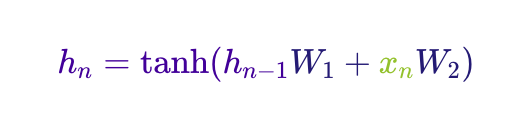

2. LSTM - 2 бонусных балла
3. GRU - 2 бонусных балла
4. Linear Recurrent Unit - 4 бонусных балла

Для реализации решения пунктов 1-3 возможно, потребуются: статья с пары, теория в учебнике, исходникам торча. 4 пункт сильно для любителей - обратитесь к статье [Resurrecting Recurrent Neural Networks for Long Sequences](https://paperswithcode.com/paper/resurrecting-recurrent-neural-networks-for). За бездумный копипаст буду карать, так что готовьтесь отвечать на вопросы, зачем та или иная строчка. За выполнение нескольких пунктов бонусные баллы суммируются.

Используйте новую ячейку, обучите вашу модель, и сравните её качество "на глаз" и по метрике с предыдущей.
В качестве метрики возьмите перплексию: https://habr.com/ru/companies/wunderfund/articles/580230/

In [ ]:
## YOUR CODE HERE

### Обучение своего transformer-а - 3 балла

А теперь предстоит заиспользовать то, что используется во всех современных генеративках - decoder блок трансформера (конечно что с self attention). Не зря ведь он был разобран на семинаре

Замените вашу RNN ячейку на собственную реализацию transformer-а. А именно, сделайте модель Decoder only.

Воспользуйтесь кодом с семинара и сделайте так, что б он обучился и имена генерировались

Используйте новую ячейку, обучите вашу модель, и сравните её качество "на глаз" и по метрике с предыдущей.
В качестве метрики возьмите перплексию: https://habr.com/ru/companies/wunderfund/articles/580230/

In [ ]:
## YOUR CODE HERE

### Генерация другого формата данных - 3 балла + бонусные 0-3 балла

Если вам наскучит решать повседневные задачи или вам нужны новые идеи, вы теперь всегда можете воспользоваться RNN или трансформером, чтобы сгенерировать что-то новое.

Вот несколько задач, от которых можно отталкиваться:
* названия статей по глубинному обучению;
* названия карт Magic The Gathering;
* [имена покемонов](https://github.com/cervoise/pentest-scripts/blob/master/password-cracking/wordlists/pokemon-list-en.txt);
* clickbait заголовки;
* молекулы в формате [smiles](https://en.wikipedia.org/wiki/Simplified_molecular-input_line-entry_system);
* ваша фантазия, с ограничениями которой вы уже должны были понять, как бороться.

Вам предлагается сделать обязательно одну какую-либо ещё задачу и, на бонусные баллы, другую.

Несколько полезных советов:
* Сейчас модель обучается на коротких строчках. Если у вас роман, его придётся порезать на кускочки.
* Если длина строк сильно варьируется, можно поставить параметр MAX_LENGTH так, чтобы он покрывал 90%. Это обычно дает ускорение примерно в 2 раза.
* Для более сложных задач требуется больше нейронов/слоев. Кроме того, можно экспериментировать и со составляющими сети (см. ниже).


In [2]:
## YOUR CODE HERE


### Ещё почитать

* [Подборка советов](https://danijar.com/tips-for-training-recurrent-neural-networks/) по обучению RNN. Чуть более полезная, чем обычно.
* Отличный блог-пост от Andrej Karpathy про языковые модели на rnn, их применение и визуализацию — [Unreasonable Effectiveness of RNN](http://karpathy.github.io/2015/05/21/rnn-effectiveness/).
* Большой список статей, постов, реализаций и прочих полезностей по RNN - [awesome rnn](https://github.com/kjw0612/awesome-rnn).
* Зоопарк готовых рекуррентных ячеек (LSTM, GRU) в [Керасе](https://keras.io/layers/recurrent/) и [PyTorch](https://pytorch.org/docs/stable/nn.html#recurrent-layers).
* Сейчас мы настраиваем количество итераций заранее. Если вы хотите определять их динамически, милости просим в [tf.while_loop](https://www.tensorflow.org/api_docs/python/tf/while_loop) или [tf.scan](https://www.tensorflow.org/api_docs/python/tf/scan).
* А ещё рекуррентные сети можно аугментировать механизмом внимания или долговременной памятью. Вот тут есть [хорошая статья](https://distill.pub/2016/augmented-rnns/).